# Análise de Séries Temporais com Pandas
Introdução à análise de séries temporais e seu uso em Data Science. Manipulação e visualização de séries temporais com Pandas. Aplicação de técnicas de previsão e decomposição de séries temporais usando bibliotecas como statsmodels ou Prophet.

**Manipulação e visualização de séries temporais com Pandas**

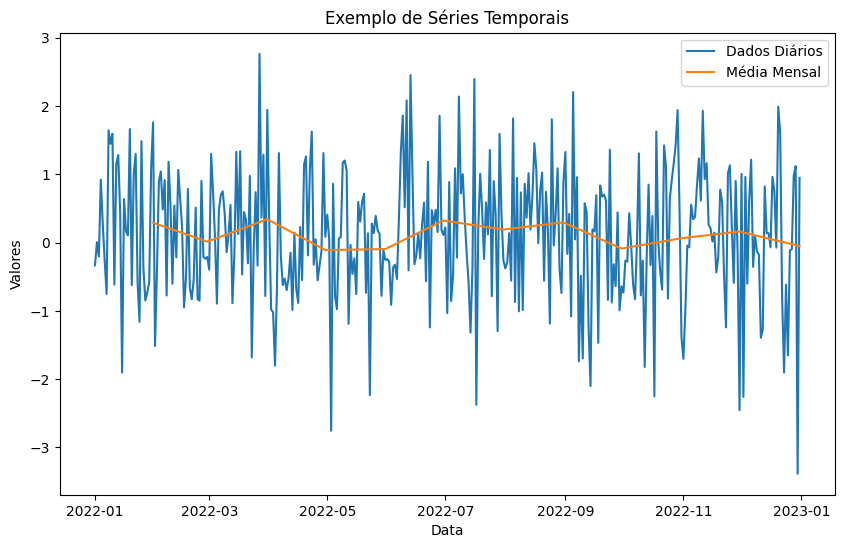

In [ ]:
import pandas as pd  # Importa a biblioteca pandas para manipulação de dados
import numpy as np   # Importa o numpy para operações numéricas
import matplotlib.pyplot as plt  # Importa o matplotlib para geração de gráficos

# Cria um intervalo de datas diárias de 01/01/2022 até 31/12/2022
datas = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')

# Gera uma série de dados aleatórios (distribuição normal) com o mesmo tamanho das datas
# Cada valor está associado a uma data como índice
dados = pd.Series(np.random.randn(len(datas)), index=datas)

# Reamostra os dados para frequência mensal ('M') e calcula a média de cada mês
dados_mensais = dados.resample('M').mean()

# Define o tamanho da figura do gráfico
plt.figure(figsize=(10,6))

# Plota os dados diários
plt.plot(dados, label='Dados Diários')

# Plota a média mensal
plt.plot(dados_mensais, label="Média Mensal")

# Define o rótulo do eixo X
plt.xlabel('Data')

# Define o rótulo do eixo Y
plt.ylabel('Valores')

# Define o título do gráfico
plt.title('Exemplo de Séries Temporais')

# Exibe a legenda para identificar as linhas
plt.legend()

# Mostra o gráfico na tela
plt.show()

**Biblioteca statsmodels**

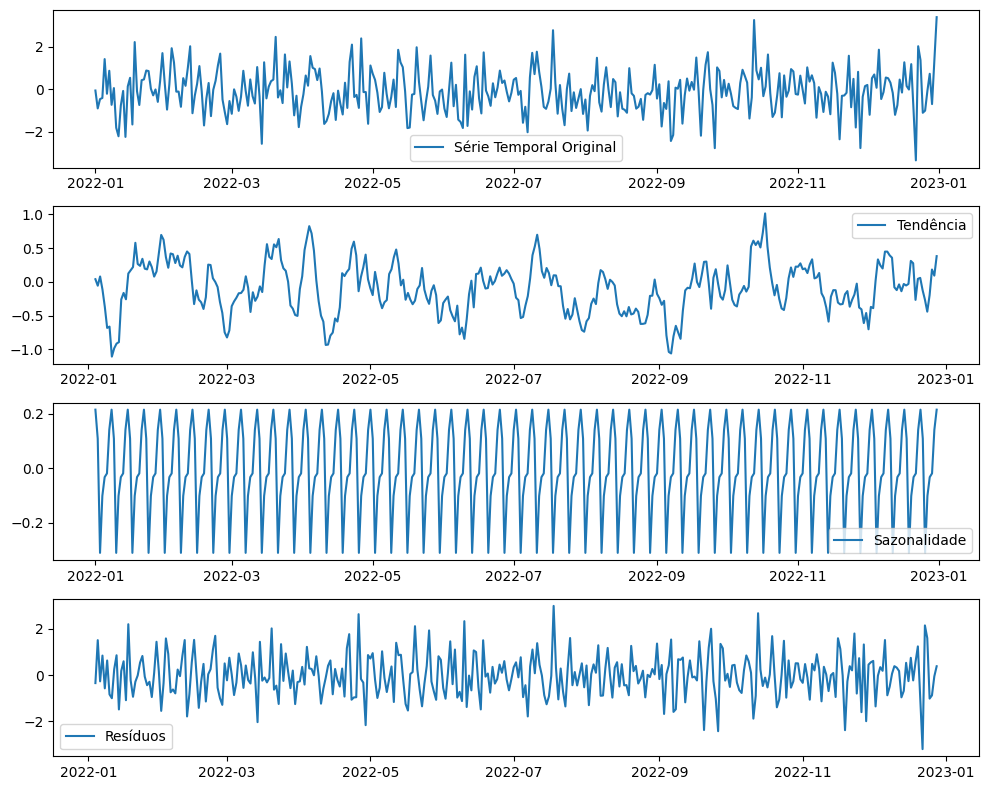

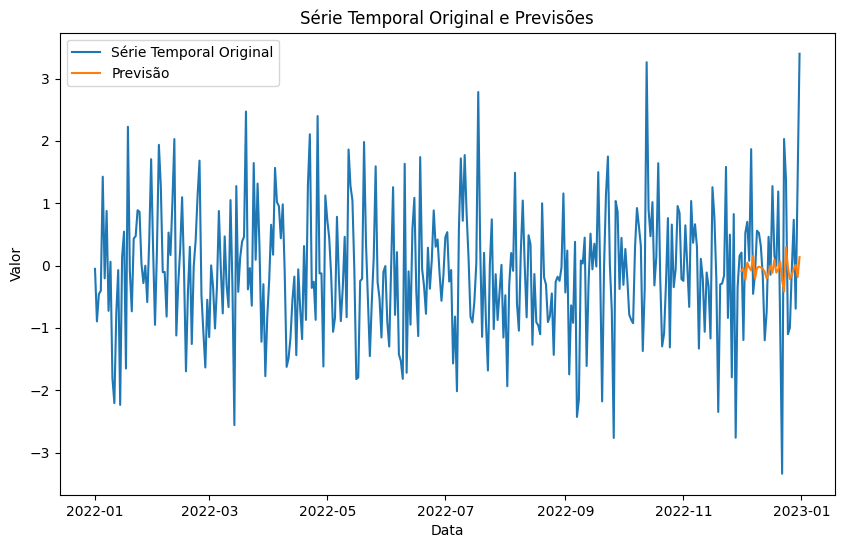

In [ ]:
import pandas as pd  # Biblioteca para manipulação de dados em formato de tabelas/séries temporais
import numpy as np   # Biblioteca para operações numéricas e geração de dados aleatórios
import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos
from statsmodels.tsa.seasonal import seasonal_decompose  # Função para decomposição de séries temporais
from statsmodels.tsa.arima.model import ARIMA  # Modelo ARIMA para previsão

# Cria um intervalo de datas diárias para o ano de 2022
datas = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')

# Gera uma série temporal com valores aleatórios (distribuição normal)
# Cada valor está associado a uma data como índice
dados = pd.Series(np.random.randn(len(datas)), index=datas)

# Decompõe a série temporal em tendência, sazonalidade e resíduos
decomposicao = seasonal_decompose(dados, model='additive')

# Cria uma figura para exibir os componentes da decomposição
plt.figure(figsize=(10,8))

# Subplot 1: série original
plt.subplot(4,1,1)
plt.plot(dados, label='Série Temporal Original')
plt.legend()

# Subplot 2: componente de tendência (trend)
plt.subplot(4,1,2)
plt.plot(decomposicao.trend, label='Tendência')
plt.legend()

# Subplot 3: componente sazonal (seasonal)
plt.subplot(4,1,3)
plt.plot(decomposicao.seasonal, label='Sazonalidade')
plt.legend()

# Subplot 4: resíduos (ruído aleatório)
plt.subplot(4,1,4)
plt.plot(decomposicao.resid, label='Resíduos')
plt.legend()

# Ajusta automaticamente o espaçamento entre os gráficos
plt.tight_layout()

# Exibe os gráficos da decomposição
plt.show()

# Cria um modelo ARIMA com parâmetros (p=1, d=0, q=1)
modelo_arima = ARIMA(dados, order=(1,0,1))

# Ajusta (treina) o modelo aos dados
modelo_arima_fit = modelo_arima.fit()

# Gera previsões para o período de dezembro de 2022
previsao = modelo_arima_fit.predict(start='2022-12-01', end='2022-12-31')

# Cria um novo gráfico para comparar dados reais e previsão
plt.figure(figsize=(10,6))

# Plota a série original
plt.plot(dados,label='Série Temporal Original')

# Plota a previsão do modelo ARIMA
plt.plot(previsao, label="Previsão")

# Define rótulos dos eixos
plt.xlabel('Data')
plt.ylabel('Valor')

# Define título do gráfico
plt.title('Série Temporal Original e Previsões')

# Exibe legenda
plt.legend()

# Mostra o gráfico final
plt.show()

**Biblioteca Prophet**

In [ ]:
# Instala a biblioteca pystan, que é usada para modelagem estatística bayesiana
# O Prophet utiliza o Stan internamente para fazer previsões
!pip install pystan

# Instala a biblioteca Prophet (antigo Facebook Prophet)
# É usada para previsão de séries temporais com foco em tendência e sazonalidade
!pip install prophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 MB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.5 MB/s eta 0:00:00


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmppovonfij/gw0smwse.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmppovonfij/shuv62hl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91967', 'data', 'file=/tmp/tmppovonfij/gw0smwse.json', 'init=/tmp/tmppovonfij/shuv62hl.json', 'output', 'file=/tmp/tmppovonfij/prophet_modelh0pjaqsq/prophet_model-20230724054353.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:43:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:43:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


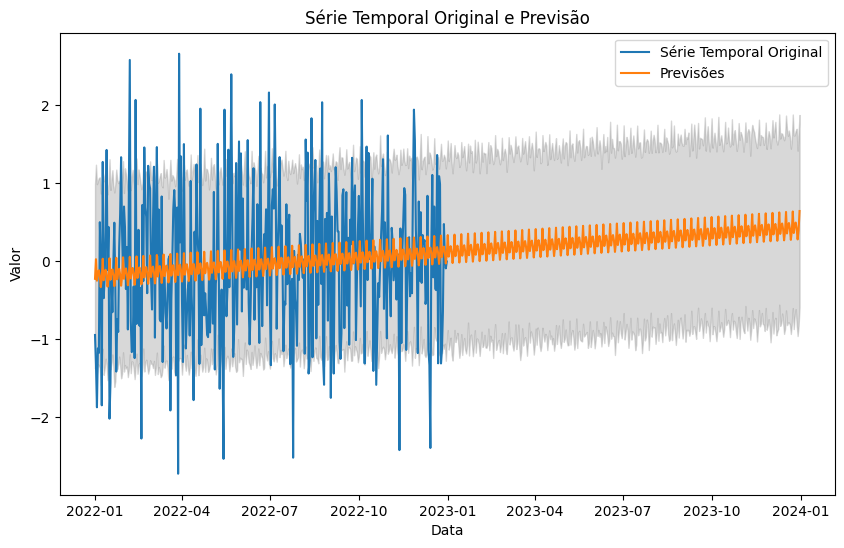

In [ ]:
import pandas as pd  # Manipulação de dados e séries temporais
import numpy as np   # Operações numéricas e geração de dados aleatórios
import matplotlib.pyplot as plt  # Criação de gráficos
from prophet import Prophet  # Modelo Prophet para previsão de séries temporais

# Cria um intervalo de datas diárias para o ano de 2022
datas = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')

# Gera uma série temporal com valores aleatórios (distribuição normal)
dados = pd.Series(np.random.randn(len(datas)), index=datas)

# Cria um DataFrame no formato exigido pelo Prophet:
# 'ds' = datas (timestamp) e 'y' = valores da série
df = pd.DataFrame({'ds': datas, 'y': dados})

# Inicializa o modelo Prophet
modelo = Prophet()

# Treina o modelo com os dados históricos
modelo.fit(df)

# Cria um DataFrame com datas futuras (365 dias à frente)
periodo_previsao = modelo.make_future_dataframe(periods=365)

# Gera as previsões para todo o período (histórico + futuro)
previsao = modelo.predict(periodo_previsao)

# Cria a figura para o gráfico
fig, ax = plt.subplots(figsize=(10,6))

# Plota a série temporal original
ax.plot(df['ds'], df['y'], label='Série Temporal Original')

# Plota a linha de previsão (yhat = valor previsto)
ax.plot(previsao['ds'], previsao['yhat'], label='Previsões')

# Plota o intervalo de confiança (incerteza da previsão)
ax.fill_between(
    previsao['ds'],
    previsao['yhat_lower'],  # limite inferior
    previsao['yhat_upper'],  # limite superior
    alpha=0.3,
    color='gray'
)

# Define rótulos dos eixos
ax.set_xlabel('Data')
ax.set_ylabel('Valor')

# Define o título do gráfico
ax.set_title('Série Temporal Original e Previsão')

# Exibe legenda
plt.legend()

# Mostra o gráfico
plt.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmppovonfij/81q6d82a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmppovonfij/z4faxg78.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=92532', 'data', 'file=/tmp/tmppovonfij/81q6d82a.json', 'init=/tmp/tmppovonfij/z4faxg78.json', 'output', 'file=/tmp/tmppovonfij/prophet_modelvy8uyy66/prophet_model-20230724055648.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:56:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:56:48 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


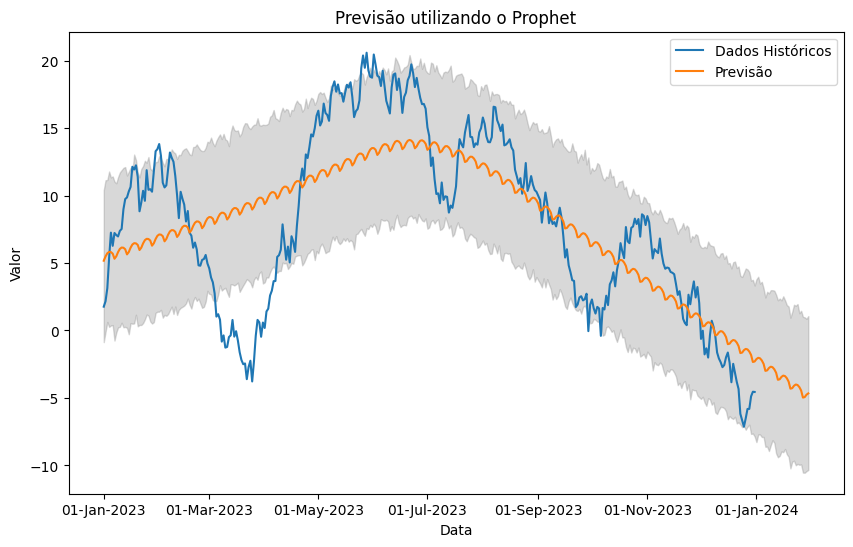

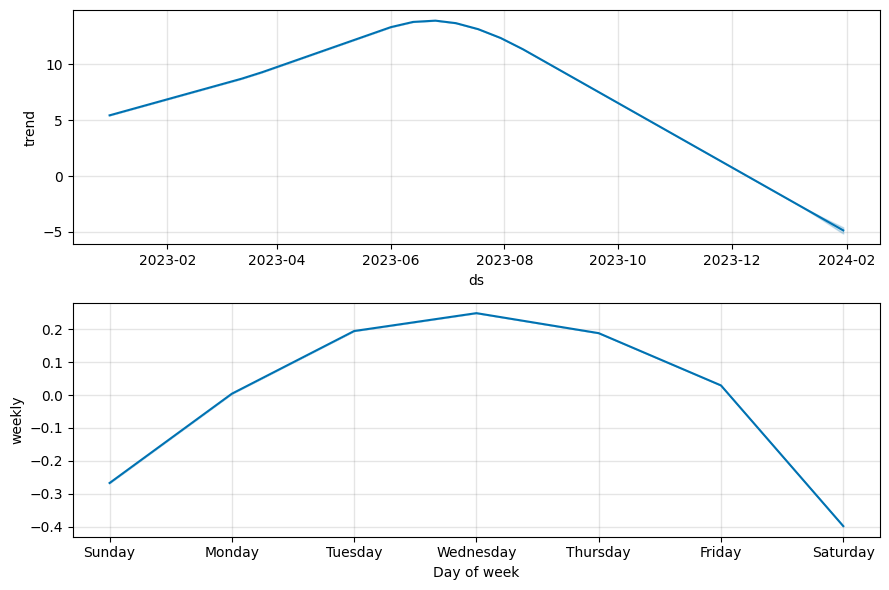

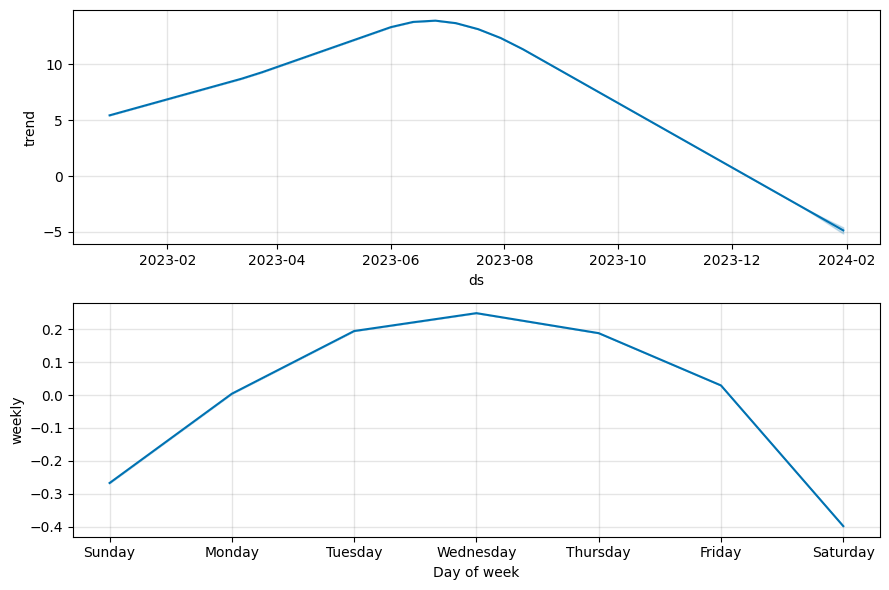

In [ ]:
import pandas as pd  # Manipulação de dados em DataFrame
import numpy as np   # Operações numéricas
from prophet import Prophet  # Modelo de previsão de séries temporais
import matplotlib.pyplot as plt  # Criação de gráficos
from matplotlib.dates import DateFormatter  # Formatação de datas no eixo X

# Define uma semente para reprodutibilidade dos resultados aleatórios
np.random.seed(0)

# Cria 365 datas a partir de 01/01/2023
datas = pd.date_range(start='2023-01-01', periods=365)

# Gera uma série com soma cumulativa de números aleatórios (simula uma tendência)
valores = np.random.randn(365).cumsum()

# Cria o DataFrame no formato exigido pelo Prophet
# 'ds' = datas | 'y' = valores
df = pd.DataFrame({'ds':datas,'y':valores})

# Inicializa o modelo Prophet
modelo = Prophet()

# Treina o modelo com os dados históricos
modelo.fit(df)

# Cria um DataFrame com 30 dias futuros
futuro = modelo.make_future_dataframe(periods=30)

# Gera as previsões (inclui histórico + futuro)
previsao = modelo.predict(futuro)

# Define o formato de exibição das datas no eixo X
date_formatter = DateFormatter('%d-%b-%Y')

# Cria figura e eixo
fig, ax = plt.subplots(figsize=(10,6))

# Plota os dados históricos
ax.plot(df['ds'],df['y'], label='Dados Históricos')

# Plota a previsão (yhat = valor previsto)
ax.plot(previsao['ds'],previsao['yhat'],label='Previsão')

# Plota o intervalo de confiança (incerteza da previsão)
ax.fill_between(
    previsao['ds'],
    previsao['yhat_lower'],  # limite inferior
    previsao['yhat_upper'],  # limite superior
    alpha=0.3,
    color='gray'
)

# Exibe a legenda
ax.legend()

# Aplica a formatação de data no eixo X
ax.xaxis.set_major_formatter(date_formatter)

# Define rótulos dos eixos
plt.xlabel('Data')
plt.ylabel('Valor')

# Define título do gráfico
plt.title('Previsão utilizando o Prophet')

# Exibe o gráfico principal
plt.show()

# Plota os componentes do modelo:
# tendência, sazonalidade semanal/anual (se detectadas)
modelo.plot_components(previsao)